In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
import struct
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from pathlib import Path


In [ ]:
data = get_data()
config, config_str = get_hmc_config(find_min = False, bias = "unified", cap = False, temp = True, umbrella = True)
find_min_config, config_find_min_str = get_hmc_config(find_min = True)
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))
print(config["nl"])

101


In [ ]:
base_dir = Path.cwd()

samples = (base_dir / f"../../../../output/age_depth_OPES/samples_{config_str}.npy").resolve()
energy_values = (base_dir / f"../../../../output/age_depth_OPES/energy_{config_str}.npy").resolve()
bias_values = (base_dir / f"../../../../output/age_depth_OPES/bias_{config_str}.npy").resolve()
resampled_samples = (base_dir / f"../../../../output/age_depth_OPES/resamp_{config_str}.npy").resolve()

samples = np.load(samples)
energy_values = np.load(energy_values)
bias_values = np.load(bias_values)
resampled_samples = np.load(resampled_samples)


In [4]:
print(energy_values)

[[ 96.61402823  97.00449879 106.09100326 ... 141.43841564 145.38620711
  142.35819245]
 [115.33516538 106.64302089 106.64302089 ... 116.78034623 120.2560179
  124.82545554]
 [ 99.00900824  99.00900824  99.00900824 ... 279.03769081 273.75126698
  278.28246514]
 [114.37167601 121.28336076 126.591547   ... 103.08835143 102.38779762
   98.80271153]
 [101.35022442 101.35022442 101.35022442 ... 200.64637008 205.54366048
  194.03596046]]


In [5]:
nl = config["nl"] if config["nl"] != None else 1
nl2 = config["nl"] if config["npc"] == 2 else 1
nt = config["nt"] if config["nt"] != None else 1
temp_colors = plt.cm.viridis(np.linspace(0,1, nt))


In [6]:
# base_dir = Path.cwd()

# files = [(base_dir / f"../../../../output/age_depth_OPES/deltaF_chain{i}_{config_str}.bin").resolve() for i in range(config["nch"])]
# # Read every 10th element along the first axis (ns)
# stride = 10
# deltaF = []

# for f in files:
#     dF_data = np.fromfile(f, dtype=np.float64)
#     # reshape to full dimensions first
#     dF_data = dF_data.reshape(config["ns"], nl, nl2, nt)
#     # take every 10th element along the first axis
#     deltaF.append(dF_data[::stride])

# deltaF = np.array(deltaF)
# print(deltaF.shape)

In [7]:
print("Reweighting energies for each temp\n")

if nt > 1:
    factors = np.arange(nt) / (nt - 1)
else:
    factors = np.array([0.0])

temp_centers = config["sbt"] * (config["ebt"] / config["sbt"]) ** factors

# Compute betas
betas = 1.0 / temp_centers

# Initial beta
beta0 = 1.0 / config["sbt"]
energy_samples = []
weights = []

for j in range(config["nt"]):
    temp_energy_samples = []
    weights = np.exp(-(betas[j] - beta0) * energy_values + bias_values)
    for i in range(config["nch"]):
        weights_i = weights[i, config["co"]:] / sum(weights[i, config["co"]:])
        indices = np.random.choice(
            np.arange(config["co"], len(weights_i) + config["co"]),
            size=int(len(weights_i)),
            replace=True,
            p=weights_i,
        )
        print(f"Chain {i} done resampling")
        temp_energy_samples.append(energy_values[i, indices])
    energy_samples.append(temp_energy_samples)
        
energy_samples = np.array(energy_samples)
print(np.shape(energy_samples))

Reweighting energies for each temp

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
(2, 5, 100000)


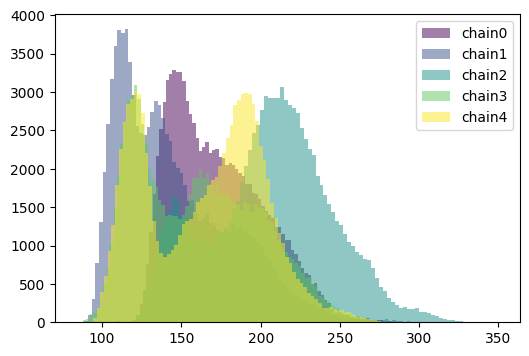

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(energy_values[i, :], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100)
plt.legend()
plt.show()   

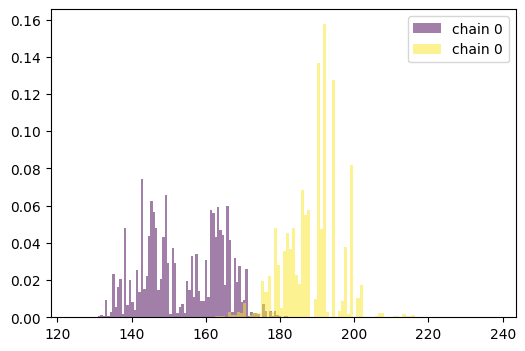

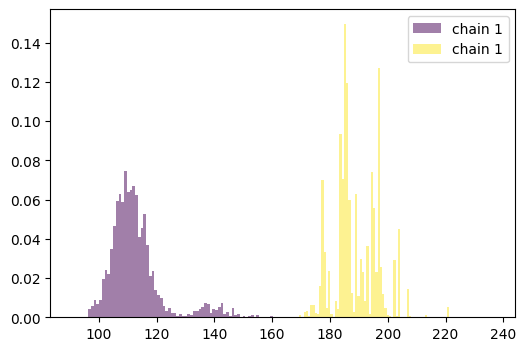

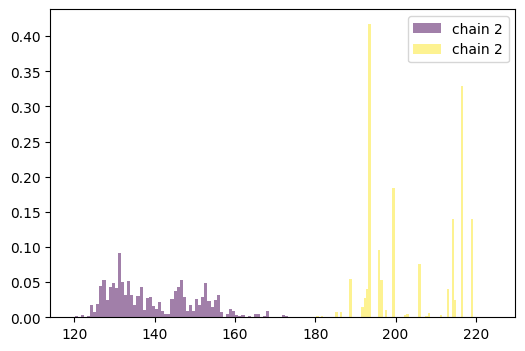

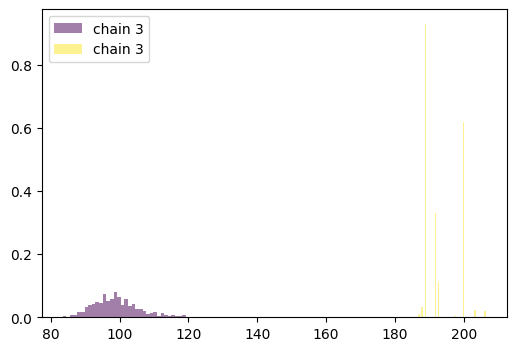

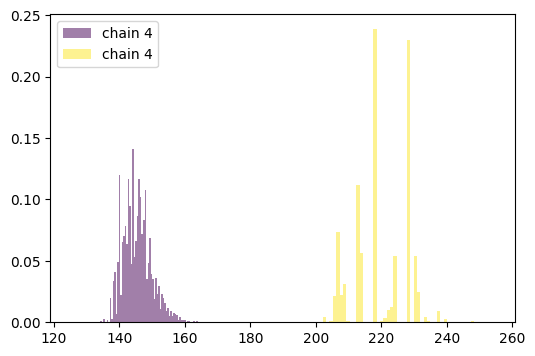

In [9]:
limit_grid = np.linspace(80, 190, 100)
bin_grid = limit_grid[:-1]

for k in range(config["nch"]):
    fig, ax = plt.subplots(figsize=(6, 4))
    for j in range(config["nt"]):
        # bin_values = np.zeros_like(bin_grid)
        # weights = np.exp(-(betas[j] - beta0) * energy_values[k, :] + bias_values[k, :])
        # for bin_idx in range(len(bin_grid)):
        #     for i, e in enumerate(energy_values[k, :]):
        #         if e > limit_grid[bin_idx] and e < limit_grid[bin_idx + 1]:
        #             bin_values[bin_idx] += weights[i]
        # print(sum(weights))
        # bin_values /= sum(weights)
        # # print(bin_values)
        # ax.plot(bin_grid + ((190-80)/100), bin_values, color = temp_colors[j])
        ax.hist(energy_samples[j, k, :], bins = 100, color = temp_colors[j], label = f"chain {k}", alpha = 0.5, density = True)
    plt.legend()
    plt.show()





In [10]:
# %matplotlib widget

# print(config["nt"])
# if (not (config["npc"] == None)):

#     if config["npc"] == 2:
#         xcoords = np.linspace(config["sb"], config["eb"], config["nl"])
#         ycoords = np.linspace(config["sb"], config["eb"], config["nl"])

#         X, Y = np.meshgrid(xcoords, ycoords)

#         for i in range(config["nch"]):
#             last_delta_F = np.squeeze(deltaF[i, -1, :, :, 9])
#             indices = np.unravel_index(np.argmin(last_delta_F), last_delta_F.shape)
#             print(deltaF[i, :, :, 0])
#             print(f"Chain {i} min deltaF at: {indices}")
#             print(xcoords[indices[0]])
#             print(ycoords[indices[1]])
#             print(f"{i}\n")
#             print(last_delta_F[last_delta_F<50])
#             plt.figure(figsize=(6,5))
#             pcm = plt.pcolormesh(X, Y, last_delta_F.T, shading='auto', cmap='viridis') # This looks flipped, could be the plotting, but could also be the indexing.
#             plt.colorbar(pcm, label='Value')
#             plt.xlabel('X coordinate')
#             plt.ylabel('Y coordinate')
#             plt.title('2D Plot with coordinates')
#             plt.show()
#     if config["npc"] == 1:
#         xcoords = np.linspace(config["sb"], config["eb"], config["nl"])

#         fig, ax = plt.subplots()

#         lines = []

#         for j in range(nt):
#             line, = ax.plot([], [], lw=2, label=f"T{j}", color = temp_colors[j])
#             lines.append(line)
#         ax.set_xlim(config["sb"], config["eb"])
#         ax.set_ylim(np.min(deltaF), np.max(deltaF))

#         ax.set_xlabel("s")
#         ax.set_ylabel("delta_F")
#         shorter_deltaF = deltaF[:, ::100, : , :, :]

#         def update(frame):
#             i = frame
#             for j in range(nt):
#                 sample_delta_F = np.squeeze(shorter_deltaF[0, i, :, 0, j])
#                 lines[j].set_data(xcoords, sample_delta_F)
#             ax.set_title(f"sample i={i}")
#             return lines,
    
#         frames = config["ns"]  # number of frames
#         ani = FuncAnimation(fig, update, frames=frames, blit=False, interval=100, repeat = False)

#         plt.show()

In [11]:
# starting_points = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/samples_min_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
# starting_energies = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/Emin_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
starting_energies_path = (base_dir / f"../../../../output/age_depth_OPES/Emin_{config_find_min_str}.npy").resolve()
starting_energies = np.load(starting_energies_path)
starting_points_path = (base_dir / f"../../../../output/age_depth_OPES/samples_min_{config_find_min_str}.npy").resolve()
starting_points= np.load(starting_points_path)
print(starting_energies)

[ 95.82593999 160.81503149  98.51794836 103.03485398 101.85631173
  96.41480715 175.364578    93.98629295 100.27035141 103.30341829
  96.9760657   92.85025439  98.77664828  95.47403137 166.73402062
 106.08955114 102.55836007  96.41503312  97.06198286 102.61538138
  97.22144971 166.97508882  98.25586272 159.29191304]


In [12]:
print(starting_points)
# print(np.sort(starting_energies))
sp_mean= np.mean(starting_points, axis = 0)
sp = starting_points-sp_mean
cov = np.cov(sp, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

print(eigenvalues)
print(np.sum(eigenvalues[0:4])/np.sum(eigenvalues))
var_ratio = eigenvalues[0] / np.sum(eigenvalues)
var2_ratio = eigenvalues[1] / np.sum(eigenvalues)
print("Main direction at problem:", pc1[20:25])
print(np.abs(pc1) > 0.1)
print("Main direction:", pc1[np.abs(pc1) > 0.1])

print(np.linalg.norm(pc1))
print(30 * np.sum(pc1[pc1>0]))
print(30 * np.sum(pc1[pc1<0]))

[[ 2.79418374  4.52858206  5.91163311 ... 15.73609938  5.46834945
   7.18668404]
 [ 3.13752277  2.735891    0.1999274  ... 14.29024138  6.35385465
   7.11896571]
 [ 2.81473448  4.55725012  5.67717706 ... 16.52889703  4.75174367
   7.11554067]
 ...
 [ 3.23114209  2.48987415  0.10409423 ... 15.78057255  4.77436232
   7.28439606]
 [ 2.80160457  4.4717735   5.70351598 ... 16.23676995  5.81824473
   7.15904583]
 [ 3.34732639  2.62277076  0.10482999 ... 15.93404328  4.91552015
   7.10454998]]
[ 2.12432906e+01  1.25917413e+01  7.35460259e+00  2.78447744e+00
  2.20309116e+00  9.95535665e-01  4.80865255e-01  4.02794040e-01
  3.00687548e-01  2.74161443e-01  1.85325715e-01  1.71530300e-01
  1.32132616e-01  9.79456360e-02  8.47269678e-02  6.50038512e-02
  5.12646374e-02  4.40106198e-02  3.56650602e-02  2.48021028e-02
  1.74941425e-02  1.48842804e-02  1.06871371e-02  1.95648036e-15
  9.15205860e-16  7.74726900e-16  4.18625995e-16  3.65118007e-16
  2.51763075e-16  2.38408187e-16  9.11332116e-17  7.2

In [ ]:
idx = starting_energies < min(starting_energies) + 30 # might bug if there are not enough starting points.
sp = sp[idx, :]
energies = starting_energies[idx]
print(energies)
sp_energies = energies[:config["nch"]]
print(sp_energies)
sp = sp[:config["nch"], :]

[ 95.82593999  98.51794836 103.03485398 101.85631173  96.41480715
  93.98629295 100.27035141 103.30341829  96.9760657   92.85025439
  98.77664828  95.47403137 106.08955114 102.55836007  96.41503312
  97.06198286 102.61538138  97.22144971  98.25586272]
[ 95.82593999  98.51794836 103.03485398 101.85631173  96.41480715]
[[-1.14218931e-01  3.95394356e-01  1.34448474e+00 -3.71415033e-01
   5.90401842e-02  1.77615062e-01 -1.60558564e-01 -1.65640237e-01
   2.15968724e+00  2.00220857e+00 -1.10056228e+00 -3.83602712e+00
  -3.61605690e-01 -5.16294066e-02  9.11406142e-02  6.30192567e-02
   8.59560739e-02 -8.30445300e-02 -1.71010620e-03  5.97370120e-02
  -5.70706447e-01  1.80232521e-01  1.97204015e-01 -1.37663714e-01
  -1.89883159e-01  2.76023773e-01 -1.74743342e-01  1.18309131e-01
  -1.27881070e-01 -8.74029663e-02  5.95861469e-02 -5.43031213e-02
  -5.72325963e-02 -1.62654489e-01  6.97965171e-01 -3.53880137e-01
   8.09649041e-03 -1.78209388e-01  1.61123947e-01 -3.89105368e-01
   3.50955735e-01  1.

c:\Users\hanna\Desktop\PhD\Bacon\bacon_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


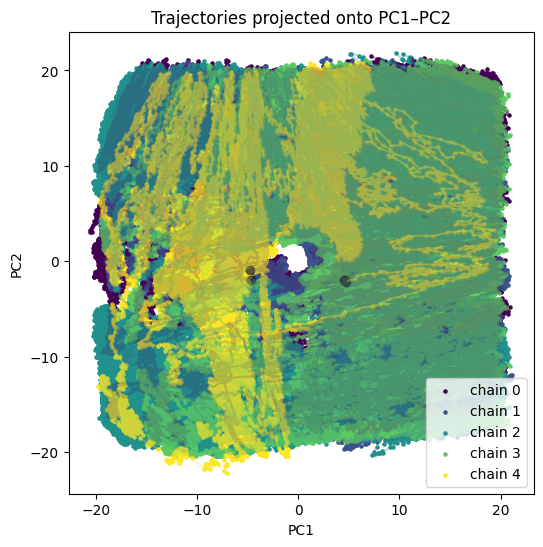

In [32]:
proj = []
for chain in range(samples.shape[0]):
    traj = samples[chain]
    traj_centered = traj - sp_mean
    coords = np.stack([traj_centered @ pc1,
                       traj_centered @ pc2], axis=1) # This should be the same as what i get when i print in C, maybe the indexing becomes wrong when i send in the pcs?
    proj.append(coords)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

for chain, coords in enumerate(proj):
    ax.plot(coords[:,0], coords[:,1], alpha=0.3, color=colors[chain])
    ax.scatter(coords[:,0], coords[:,1], s=5, color=colors[chain], label=f"chain {chain}")

ax.scatter(sp @ pc1, sp @ pc2, color = 'black', marker = 'o')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectories projected onto PC1–PC2") # Something is weird, adding the exploration in pc2 makes it explore worse in pc1, something is still wrong.
ax.legend()
plt.show()

In [15]:
print(np.shape(resampled_samples))
print(np.shape(samples))

(5, 100000, 50)
(5, 100000, 50)


In [16]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [17]:
print(energy_values)

[[ 96.61402823  97.00449879 106.09100326 ... 141.43841564 145.38620711
  142.35819245]
 [115.33516538 106.64302089 106.64302089 ... 116.78034623 120.2560179
  124.82545554]
 [ 99.00900824  99.00900824  99.00900824 ... 279.03769081 273.75126698
  278.28246514]
 [114.37167601 121.28336076 126.591547   ... 103.08835143 102.38779762
   98.80271153]
 [101.35022442 101.35022442 101.35022442 ... 200.64637008 205.54366048
  194.03596046]]


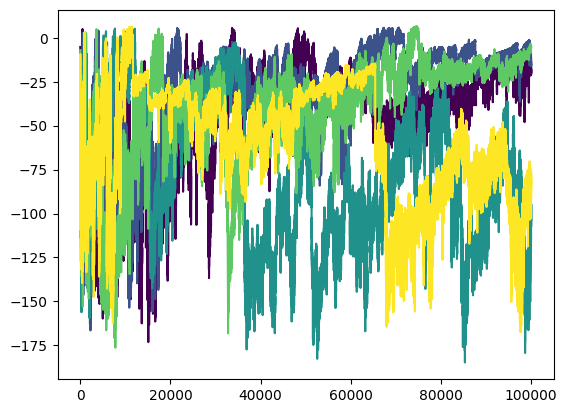

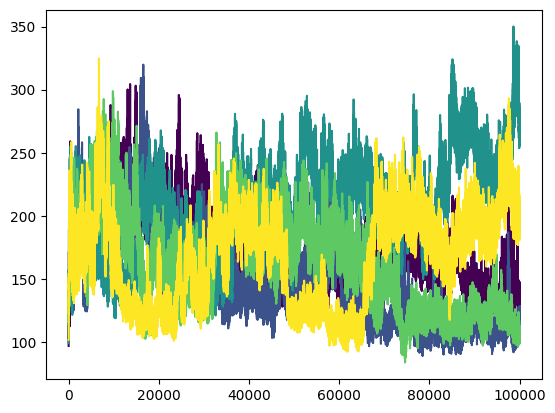

In [18]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:], color = colors[i])
plt.show()


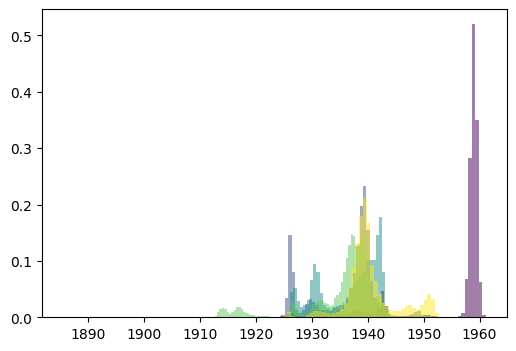

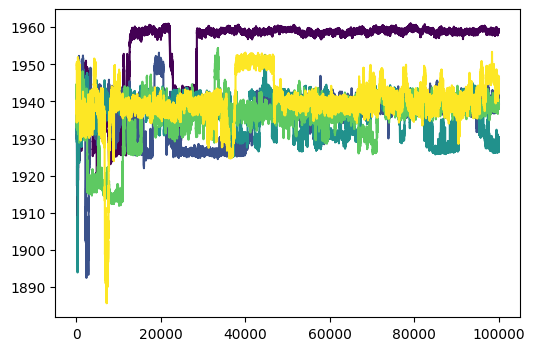

In [19]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :4], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

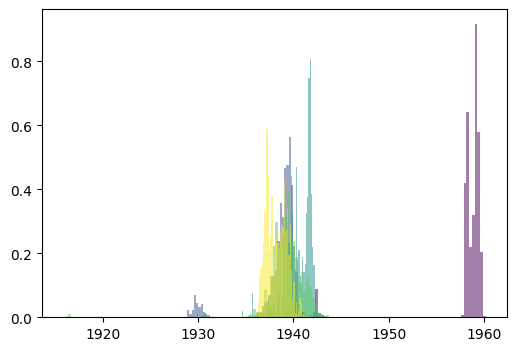

In [20]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :4], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

In [21]:
resampled_samples = resampled_samples[:,::100,:]

In [22]:
print(np.max(bias_values))

6.405793739329762


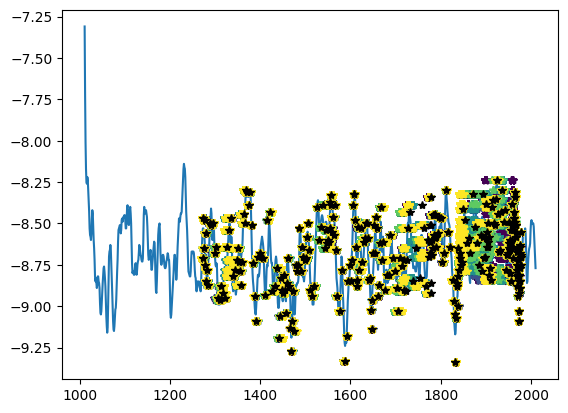

In [23]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [24]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    2.75   0.20    2.36     3.11       0.03     0.01     35.85    139.61   
x[1]    4.70   0.50    3.87     5.61       0.12     0.05     17.51     87.80   
x[2]    4.96   1.95    1.00     7.07       0.78     0.56     11.99     29.55   
x[3]    5.11   2.60    0.24     7.73       1.04     0.64      8.52     27.93   
x[4]    4.06   3.14    0.05     7.95       1.09     0.43      7.67     28.23   
x[5]    5.16   4.75    0.16    14.68       2.00     1.20      5.96     24.42   
x[6]    3.26   2.52    0.34     7.11       0.77     0.18      8.40     26.54   
x[7]   10.85  11.96    0.10    29.19       5.20     1.52      6.38     24.56   
x[8]    2.87   3.01    0.04     8.25       0.59     0.20     19.29     27.28   
x[9]    7.43  12.04    0.37    46.07       3.33     4.48     10.27     27.37   
x[10]   8.45  11.17    0.05    41.35       3.50     3.97      7.79     26.72   
x[11]   4.10   5.77    0.02    15.37    

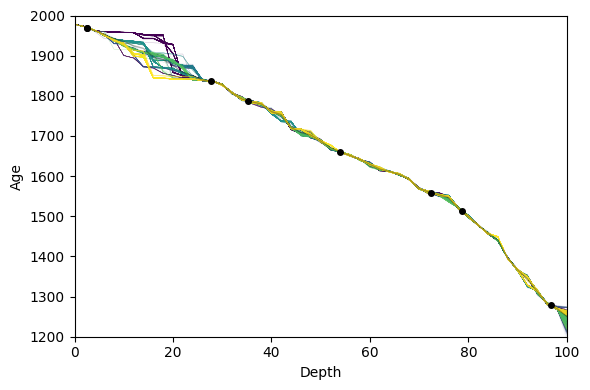

In [25]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
# for i, c in enumerate(config["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

In [26]:
depths = np.sort(np.hstack((0, data["d18O_depths"])))
ages = np.flip(np.hstack((data["theta"], data["true_ages_D18O"]))) # why are they not sorted correctly?
# print(depths)
# print(ages)
sed_rates = [0]
theta = data["theta"]

pre_age = theta
pre_depth = 0
for i in range(1, config["N"] + 1):
    idx = np.searchsorted(depths, config["cs"][i])
    # print(np.sort(depths))
    # print(config["cs"][i])
    # print(idx)
    if idx < len(depths):
        upper_depth = depths[idx - 1]
        age = ages[idx - 1] + ((ages[idx] - ages[idx - 1])/(depths[idx] - depths[idx - 1]))*(config["cs"][i] - depths[idx-1])
        sed_rates.append((pre_age - age) / (config["cs"][i] - config["cs"][i-1]))
        pre_age = age
    else:
        sed_rates.append(config["a"] / config["b"])


print(sed_rates)
exp_ages = theta - np.cumsum(sed_rates) * config["dc"]
print(exp_ages)
print(np.max(sed_rates))

[0, np.float64(2.961999999999989), np.float64(4.918999999999983), np.float64(5.424000000000092), np.float64(7.48792682926819), np.float64(6.232073170731724), np.float64(4.960348837209267), np.float64(3.886079734219379), np.float64(2.3600487012986378), np.float64(3.077159090909049), np.float64(5.722077922077915), np.float64(10.704053156146301), np.float64(8.34939922480612), np.float64(3.580958333333342), np.float64(2.1794903846154057), np.float64(5.24633699633705), np.float64(10.239729437229357), np.float64(6.853863636363712), np.float64(2.800787878787901), np.float64(2.2284166666665897), np.float64(1.326249999999959), np.float64(3.7012500000000728), np.float64(11.959886363636315), np.float64(13.616363636363644), np.float64(9.235416666666652), np.float64(8.99635416666672), np.float64(7.4015624999999545), np.float64(4.2762943262411), np.float64(4.733872340425592), np.float64(4.755707317073188), np.float64(5.887838137472272), np.float64(6.097495361781057), np.float64(3.2143877551020523), 

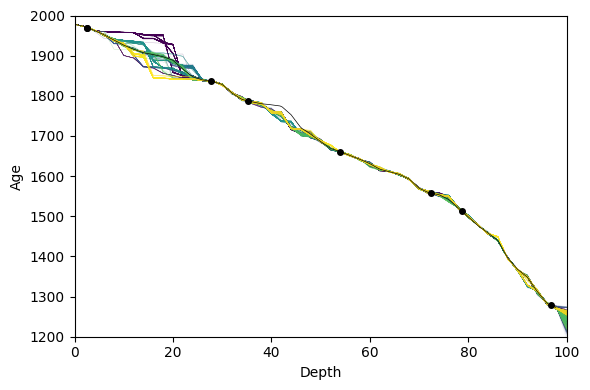

In [27]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
# for i, c in enumerate(config["cs"]):
#     if i != config["pidx"]:
#         ax.axvline(x=c, color='k', linestyle='--')
#     else:
#         ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
# plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(config["cs"], exp_ages, color = 'r', linewidth = 0.5)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.plot(data["d18O_depths"], data["true_ages_D18O"], color = 'k', linewidth=0.5)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()